# Task 1: Superstore Data Analysis
Pride MJ Mnisi


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("SuperstoreDataSample.csv", encoding="cp1252")

#Useful Variables
font_title = {'family': 'times new roman', 'color': 'black', 'size': 16, 'weight': 'bold'}
font_labels = {'family': 'times new roman', 'color': 'black', 'size': 14}
grid_dict = {'color': 'black', 'linestyle': '--', 'linewidth': 0.5, 'alpha': 0.7}

## Data Inspection
Understanding the data

### The available heads of the data:

In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit;'],
      dtype='str')

The Profit header seems to be the only header which requires cleaning.

### Information about Columns

The the number of non-null values, data types of each column and memory usage of the DataFrame. 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   str    
 1   Order ID       7484 non-null   str    
 2   Order Date     7484 non-null   str    
 3   Ship Date      7484 non-null   str    
 4   Ship Mode      7484 non-null   str    
 5   Customer ID    7484 non-null   str    
 6   Customer Name  7484 non-null   str    
 7   Segment        7484 non-null   str    
 8   Country        7484 non-null   str    
 9   City           7484 non-null   str    
 10  State          7484 non-null   str    
 11  Postal Code    7484 non-null   float64
 12  Region         7484 non-null   str    
 13  Product ID     7484 non-null   str    
 14  Category       7484 non-null   str    
 15  Sub-Category   7484 non-null   str    
 16  Product Name   7484 non-null   str    
 17  Sales          7484 non-null   float64
 18  Quantity       7484

This is useful for understanding the structure of our data and identifying any potential issues with missing values or incorrect data types.

Notable issues:
- Incorrect date formats
- Incorrect Profit data type

### Amount of Null values

In [5]:
df.isnull().sum()

Row ID              0
Order ID         2510
Order Date       2510
Ship Date        2510
Ship Mode        2510
Customer ID      2510
Customer Name    2510
Segment          2510
Country          2510
City             2510
State            2510
Postal Code      2510
Region           2510
Product ID       2510
Category         2510
Sub-Category     2510
Product Name     2510
Sales            2510
Quantity         2510
Discount         2510
Profit;          2510
dtype: int64

These are rows to be filtered out

### Data Description

    Summary statistics for the numerical columns in our DataFrame, such as count, mean, standard deviation, minimum, and maximum values. 
    This helps us get a quick overview of the distribution and central tendencies of our numerical data.

In [6]:
df.describe()

,Postal Code,Sales,Quantity,Discount
count,7484.000000,7484.000000,7484.000000,7484.000000
mean,55587.591529,246.987420,3.776991,0.154969
std,31990.451627,674.440108,2.212994,0.205513
min,1040.000000,0.444000,1.000000,0.000000
25%,23602.000000,16.272000,2.000000,0.000000
50%,60035.000000,54.580000,3.000000,0.200000
75%,90008.000000,223.920000,5.000000,0.200000
max,99301.000000,22638.480000,14.000000,0.800000


# Data cleaning

### Dropping missing values

In [7]:
df = df.dropna()
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit;          0
dtype: int64

### Formatting Profits

In [8]:
df.rename(columns={'Profit;': 'Profit'}, inplace=True)
print("The profit column name is: Profit")

print(df.loc[0:4, 'Profit'])
df['Profit'] = df['Profit'].str.replace(';', '')
df['Profit']= df['Profit'].astype(float)
print()
print("The profit column data type is: ", df['Profit'].dtype)
print(df.loc[0:4, 'Profit'])

The profit column name is: Profit
0     41.9136;
2      6.8714;
3    -383.031;
4      2.5164;
Name: Profit, dtype: str

The profit column data type is:  float64
0     41.9136
2      6.8714
3   -383.0310
4      2.5164
Name: Profit, dtype: float64


### Formatting Dates

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
#Exporting clean data frame (file writing)
df.to_csv("output.csv", index=False)



---

# Data Analysis

## Revenue Analysis

This section analyses the sales and profit made throughout the year and aims to give clear insights on the periods at which the business does well and the periods at which it does not.

### Annual Sales

Annual Sales:
Order Date
2014    394984.5790
2015    374186.0346
2016    476090.1966
2017    603193.0423
Name: Sales, dtype: float64
Annual Profit:
Order Date
2014    40646.9455
2015    55750.8828
2016    65006.7657
2017    81080.4922
Name: Profit, dtype: float64


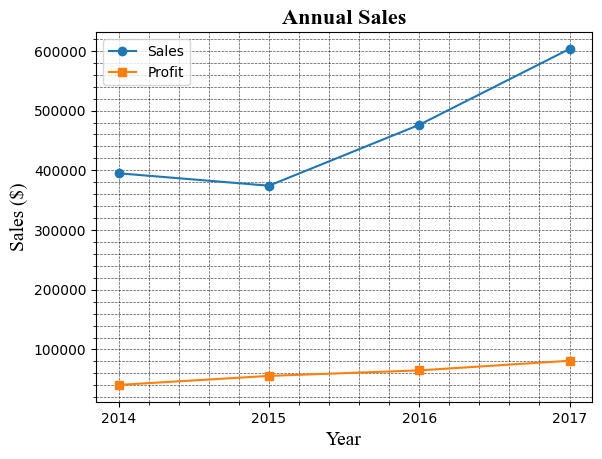

In [10]:
years = df['Order Date'].dt.year
sale_group_obj = df.groupby(years)
annual_sales = sale_group_obj['Sales'].sum()
print("Annual Sales:")
print(annual_sales)
annual_profit = sale_group_obj['Profit'].sum()
print("Annual Profit:")
print(annual_profit)



plt.plot(annual_sales.index, annual_sales, marker='o')
plt.plot(annual_sales.index, annual_profit, marker='s')
plt.title('Annual Sales', fontdict=font_title)
plt.xlabel('Year', fontdict=font_labels)
plt.ylabel('Sales ($)', fontdict=font_labels)
plt.minorticks_on()
plt.grid(True, **grid_dict, which='both') 
plt.xticks(annual_sales.index)
plt.legend(['Sales', 'Profit'])

plt.show()


**Key Observations**

- Anual Sales

    Annual sales show a clear upward trend from 2015 to 2017, indicating strong business growth after a slight dip in 2015.

    The significant increase between 2016 and 2017 suggests that business strategies implemented during this period were highly effective in driving revenue.

- Profit

    Profit follows a consistent upward trend, increasing each year.

    This indicates that the business is not only generating more revenue but is also maintaining profitability as it scale

    Although, there has been a significant gap between the anual sales measured to be approximately, 345k in 2014 and 522k in 2017, meaning the gap has increased

**Insight**

Overall the anual sales grow at a greater rate than anual profit. This could be due to a number of factors, such as increased costs, lower profit margins, or a shift towards lower-margin products. Further analysis is required to identify the exact cause and improve overall profitability.

### Monthly Sales

Monthly Sales:
Month 01: 81338.11
Month 02: 39355.75
Month 03: 174336.52
Month 04: 107640.23
Month 05: 133014.80
Month 06: 119218.77
Month 07: 116307.54
Month 08: 136272.99
Month 09: 239506.17
Month 10: 160324.55
Month 11: 283324.20
Month 12: 257814.22

Monthly Profit:
Month 01: 7404.89
Month 02: 6412.40
Month 03: 25586.94
Month 04: 7671.45
Month 05: 20486.76
Month 06: 18327.06
Month 07: 11805.62
Month 08: 18911.39
Month 09: 32772.81
Month 10: 28118.05
Month 11: 28877.38
Month 12: 36110.33


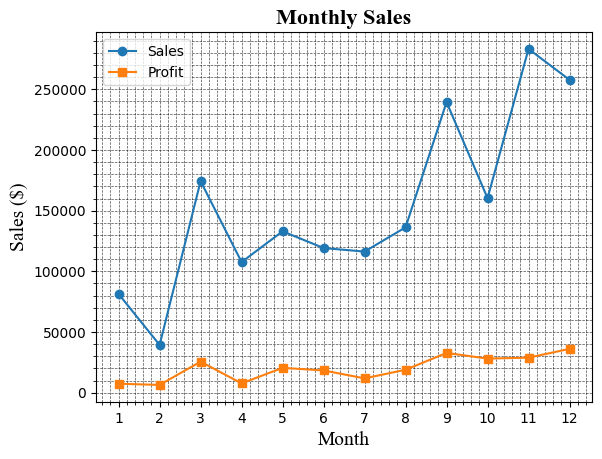

In [11]:
months = df['Order Date'].dt.month
sale_group_obj = df.groupby(months)
monthly_sales = sale_group_obj['Sales'].sum()
monthly_profit = sale_group_obj['Profit'].sum()

print("Monthly Sales:")
for month, sales in monthly_sales.items():
    print(f"Month {month:02d}: {sales:.2f}")

print("\nMonthly Profit:")
for month, profit in monthly_profit.items():
    print(f"Month {month:02d}: {profit:.2f}")


plt.plot(monthly_sales.index, monthly_sales, marker='o')
plt.plot(monthly_profit.index, monthly_profit, marker='s')
plt.title('Monthly Sales', fontdict=font_title)
plt.xlabel('Month', fontdict=font_labels)
plt.ylabel('Sales ($)', fontdict=font_labels)
plt.minorticks_on()
plt.grid(True, **grid_dict, which='both')
plt.xticks(monthly_sales.index)
plt.legend(['Sales', 'Profit'])

plt.show()


**Key Observations**

- Early-Year Dip

    Both sales and profit are significantly lower in January and February, with February being the lowest-performing month.

    This suggests a post-holiday slowdown, where customer spending typically decreases after the festive season.

- Mid-Year Recovery

    From March onward, there is a sharp increase in sales, followed by moderate fluctuations between April and August.

    This indicates a period of stabilized business activity, where sales are consistent but not at peak levels.

- Late-Year Surge

    A strong upward trend is observed from September through December, with:

    1. A major peak in November
    2. Sustained high performance in December

    Profit follows a similar pattern, confirming that this is the most valuable period for the business.

**Insight**

The business shows clear seasonal behavior:

1. Weak performance at the start of the year
2. Strong performance toward the end of the year

**Reccomendations**

To improve overall performance, the business should **focus on boosting sales during the slower early months** while fully capitalizing on the high-demand period at the end of the year.

---

## Regional Perfomance

### Overview

This section analyzes sales performance across 4 regions: West, East, Central, and South using Sales, Profit, and Profit Margin.


### Sales by Region

Region
West       595400.5800
East       523368.9800
Central    411913.2230
South      317771.0695
Name: Sales, dtype: float64


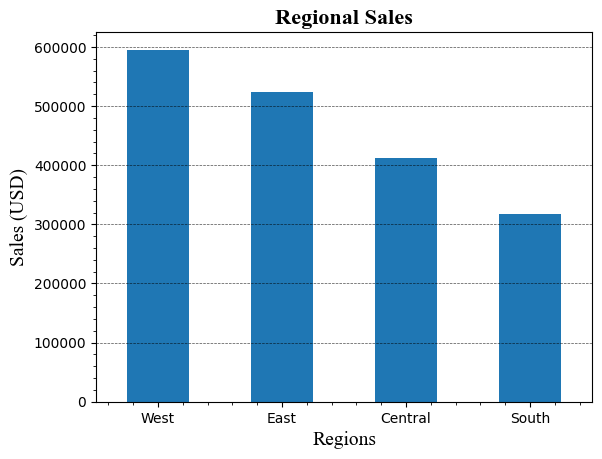

In [12]:
region_group_obj = df.groupby('Region')
region_sales = region_group_obj['Sales'].sum().sort_values(ascending=False)

print(region_sales)
region_sales.plot(kind='bar')
plt.title('Regional Sales', fontdict=font_title, horizontalalignment='center')
plt.xlabel('Regions', fontdict=font_labels)
plt.ylabel('Sales (USD)', fontdict=font_labels)
plt.grid(True, **grid_dict, axis='y')
plt.minorticks_on()
plt.xticks(rotation=0)
plt.show()

**Key Observations**

- Top Performing Region

    The West region generates the highest sales, followed closely by the East.

    This indicates that these regions are the **primary drivers** of revenue for the business.

- Mid-Level Performance

    The Central region shows moderate performance, contributing a significant portion but still trailing behind the top regions.

- Underperforming Region

    The South region records the lowest sales, generating substantially less revenue than all other regions.

    Compared to the West, the South generates approximately 47% less revenue, highlighting a clear performance gap.

**Insight**

There is a clear imbalance in regional performance, with revenue concentrated in the West and East.

This could be due to:

1. Differences in market demand
2. Unequal resource allocation
3. Variations in marketing effectiveness
4. Regional economic factors

**Recommendations**

1. Investigate South Region Performance

    1. Analyze customer behavior and demand in the South
    2. Evaluate whether the region is under-marketed or under-supplied
    3. Identify barriers such as pricing, logistics, or product fit

2. Leverage High-Performing Regions

    Study strategies used in the West and East and consider implimenting them in the under performingregions

3. Optimize Resource Allocation

    Consider redistributing marketing and operational efforts
    Focus on high-growth potential regions while improving weaker ones

### Profits by Regions

Region
West       91416.0814
East       77069.6024
Central    38877.7150
South      35121.6874
Name: Profit, dtype: float64


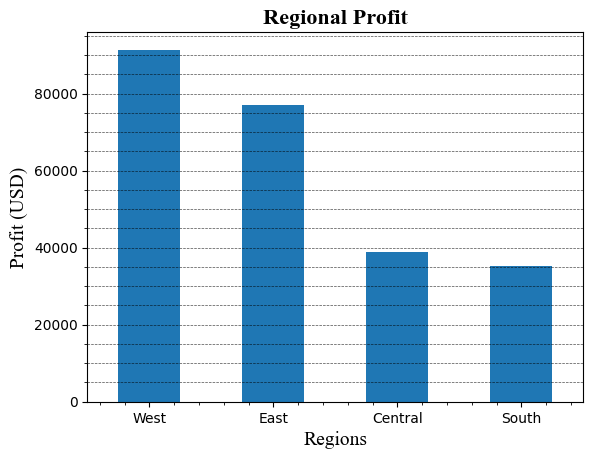

In [20]:
profit_group_obj = df.groupby('Region')
profit_group = profit_group_obj['Profit'].sum().sort_values(ascending=False)

print(profit_group)
profit_group.plot(kind='bar')
plt.title('Regional Profit', fontdict=font_title, horizontalalignment='center')
plt.xlabel('Regions', fontdict=font_labels)
plt.ylabel('Profit (USD)', fontdict=font_labels)
plt.grid(True, **grid_dict, axis='y', which='both')
plt.minorticks_on()
plt.xticks(rotation=0)
plt.show()

**Key Observations**

- Top Performing Regions

    The West region generates the highest profit, approximately $91k, followed by the East, consistent with the trend observed in sales.

    This indicates that these regions are not only generating high revenue but are also maintaining strong profitability.


- Central Region Concern

    The Central region generates relatively high sales (approx. 412k) but significantly lower profit (approx. 8.9k).

    This suggests a low return on sales, indicating potential issues such as:

    1. High operational or shipping costs

    2. Heavy discounting

    3. Lower-margin products

-  South Region Efficiency

    Although the South region has the lowest sales (approx. 317k), its profit (approx. 35k) is very close to that of the Central region.

    This indicates that the South is operating with better efficiency, achieving similar profit levels with significantly lower sales.


**Insight:**

There is a clear difference between revenue generation and profit efficiency across regions.

The Central region appears to be underperforming in terms of profitability
The South region, despite lower sales, is relatively more efficient


**Recommendations:**

1. Investigate Central Region Costs

    Analyze cost structure (logistics, discounts, operations)
    Identify areas where profit margins are being reduced
    Optimize pricing or reduce unnecessary expenses

2. Learn from South Region Efficiency

    Identify what is working well in the South
    Replicate efficient practices in other regions, especially Central

3. Strengthen High-Profit Regions

    Continue investing in West and East, as they drive both revenue and profit
    Scale successful strategies from these regions

### Profit margins

West: 15.35 %
East: 14.73 %
Central: 9.44 %
South: 11.05 %


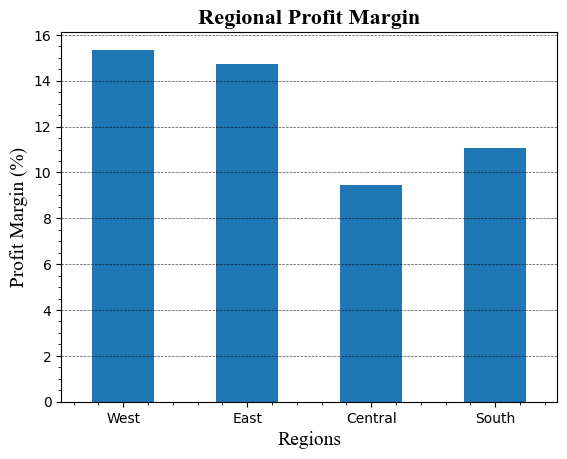

In [14]:
profit_margin = (profit_group / region_sales) * 100
for region, profit in profit_margin.items():
    print(f"{region}: {profit:.2f} %")

profit_margin.plot(kind='bar')
plt.title('Regional Profit Margin', fontdict=font_title, horizontalalignment='center')
plt.xlabel('Regions', fontdict=font_labels)
plt.ylabel('Profit Margin (%)', fontdict=font_labels)
plt.grid(True, **grid_dict, axis='y')
plt.minorticks_on()
plt.xticks(rotation=0)
plt.show()

**Key Observations**

- High-Performing Regions

    The West and East regions have the highest profit margins, indicating strong cost control and efficient operations.

- Moderate Performance

    The South region shows moderate efficiency, maintaining a reasonable margin despite lower overall sales.

- Critical Concern: Central Region

    The Central region has the lowest profit margin (9.44%), confirming earlier observations that it is underperforming in terms of profitability.

    This reinforces that:

    1. High sales ≠ high profit

    2. The Central region is likely experiencing cost inefficiencies or aggressive discounting
 

**Insight**

Profit margin reveals the true performance of each region:

West/East: Strong revenue and strong efficiency which is why they are best-performing regions


South: Lower revenue but decent efficiency so, it is fairly stable
Central: High revenue but poor efficiency Meaning there is prioritising issues


**Recommendations** 

1. Fix Central Region Profitability (High Priority)
    
    1. Review products in the Central region with:
        1. Discount rates > 15%
        2. Low profit margins
    
    2. Target:
        Increase Central region profit margin from 9.44% → at least 12% within 2 quarters

2. Audit pricing strategies in Central:
    1. Identify products consistently sold at reduced margins
    2. Implement minimum margin thresholds to prevent loss-leading sales

3. Shift focus toward:
    1. High-margin products
    2. Bundled offerings instead of heavy discounts
    3. Reducig reliance on low-margin, high-volume items

4. Replicate High-Performing Region Strategies

---

## Categories

Category
Technology         789020.6400
Office Supplies    580847.7300
Furniture          478585.4825
Name: Sales, dtype: float64

Category Data (Sales & Profit):
                       Sales       Profit
Category                                 
Technology       789020.6400  135977.9624
Office Supplies  580847.7300   97555.1085
Furniture        478585.4825    8952.0153


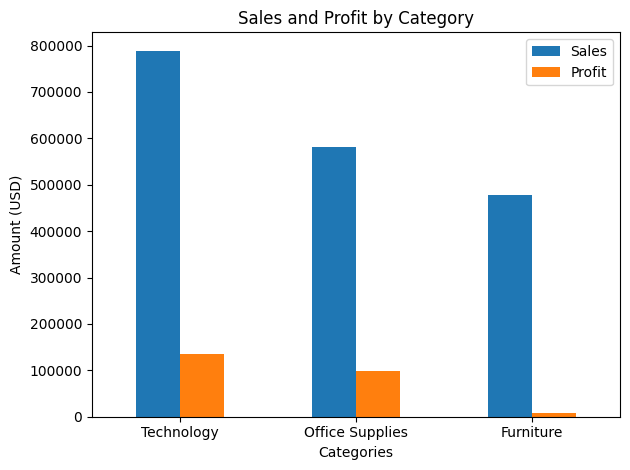

In [15]:
categories_grp_obj = df.groupby('Category')
sales_by_category = categories_grp_obj['Sales'].sum().sort_values(ascending=False)
print(sales_by_category)

profit_by_category = categories_grp_obj['Profit'].sum().sort_values(ascending=False)

# Create DataFrame for grouped bar chart (sorted by sales)
category_df = pd.DataFrame({
    'Sales': sales_by_category,
    'Profit': profit_by_category
}).sort_values('Sales', ascending=False)

print("\nCategory Data (Sales & Profit):")
print(category_df)

# Grouped bar chart
category_df.plot(kind='bar', xlabel='Categories', ylabel='Amount (USD)', title='Sales and Profit by Category')
plt.xticks(rotation=0)
plt.legend(['Sales', 'Profit'])
plt.tight_layout()
plt.show()


**Key Observations**

The ratio between the sales vs profit is large due to category being broad.

- Top Performing Category: Technology

    Technology generates the highest sales and the highest profit by a large margin.

    This indicates:

    1. Strong demand
    2. High-margin products
    3. Effective pricing strategy

- Stable Performer: Office Supplies

    Office Supplies shows solid performance in both sales and profit, making it a reliable contributor to overall business revenue.

- Critical Issue: Furniture Category

    Furniture generates significant sales (~478k) but extremely low profit (approx. 8.9k).

    This a profit margin of roughly:

    ~1.9% (very low compared to other categories)

    This suggests:

    1. High costs (shipping, production, storage)
    2. Heavy discounting
    3. Low-margin products


**Insight**

Technology contributes the most to business growth and is the profit driver. Office Supplies are the stable backbone pf the business. Lastly Furniture is where the problem area (revenue without value)

**Recommendations**

1. Fix Furniture Profitability (High Priority)
    Identify top-selling furniture products with low margins

2. Reduce Loss-Making or Low-Margin Products

3. Increase marketing and inventory for Technology products
Expand product range in high-performing sub-categories

---

## Top-Selling Products

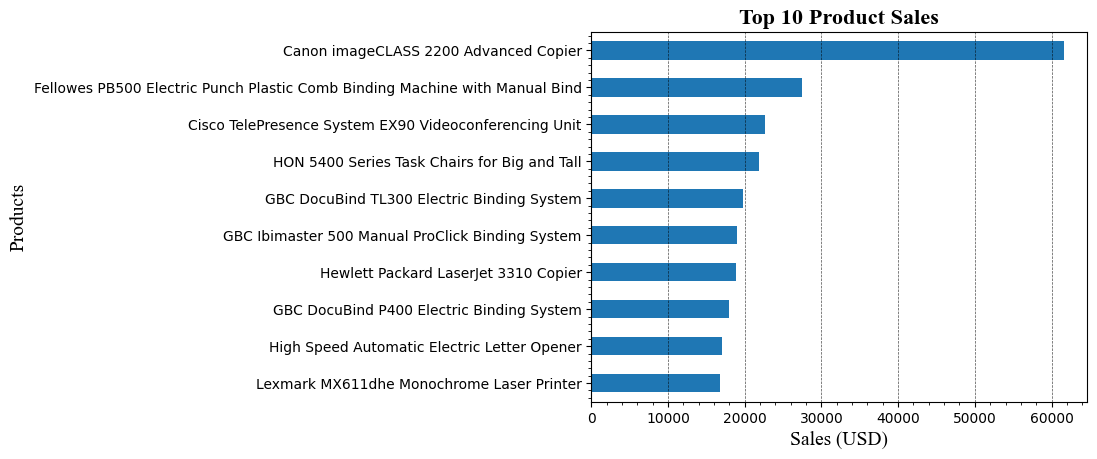

Product Name
Lexmark MX611dhe Monochrome Laser Printer                                      16829.901
High Speed Automatic Electric Letter Opener                                    17030.312
GBC DocuBind P400 Electric Binding System                                      17965.068
Hewlett Packard LaserJet 3310 Copier                                           18839.686
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
GBC DocuBind TL300 Electric Binding System                                     19823.479
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Name: Sales, dtype: float64


In [16]:
sale_group_obj = df.groupby('Product Name')
product_sales = sale_group_obj['Sales'].sum().sort_values(ascending=True).tail(10)
product_sales.plot(kind='barh')
plt.title('Top 10 Product Sales', fontdict=font_title, horizontalalignment='center')
plt.xlabel('Sales (USD)', fontdict=font_labels)
plt.ylabel('Products', fontdict=font_labels)
plt.grid(True, **grid_dict, axis='x')
plt.minorticks_on()
plt.show()
print(product_sales)

**Key Observations**

- Technology Dominance

    Many of the top products fall under the Technology category, reinforcing earlier findings that technology is the **primary revenue driver** of the business

- Furniture Presence 

    Products like task chairs appear among top sellers, but earlier analysis showed Furniture has low profit.

    This suggests furniture products may sell well, but are likely low-margin or high-cost

**Insight**

High-value products seem to drive revenue
A strong Technology segment for profitability

However, some top-selling products may not be highly profitable, especially in categories like Furniture

**Recommendations**

1. Identify which of these top-selling products:
Have low or negative profit margins

2. Prioritize High-Profit Products
    Focus marketing and promotions on:
    Products with both high sales AND high profit

3. Optimize supply chain costs

4. Bundle high-margin + high-demand products

5. Invest more in Technology Category since its products are the top sellers

---

## Segments

### Sales

Segment
Consumer       936507.1928
Corporate      554778.0364
Home Office    357168.6233
Name: Sales, dtype: float64


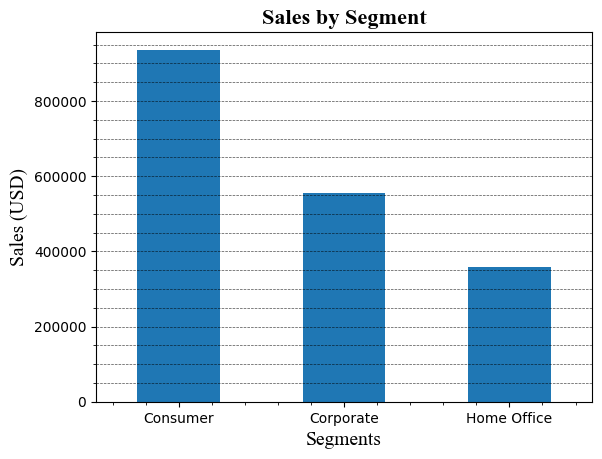

In [17]:
seg_grp_obj = df.groupby('Segment')
sales_by_segment = seg_grp_obj['Sales'].sum().sort_values(ascending=False)
print(sales_by_segment)
sales_by_segment.plot(kind='bar')
plt.title('Sales by Segment', fontdict=font_title, horizontalalignment='center')
plt.xlabel('Segments', fontdict=font_labels)
plt.ylabel('Sales (USD)', fontdict=font_labels)
plt.grid(True, **grid_dict, axis='y', which='both')
plt.minorticks_on()
plt.xticks(rotation=0)
plt.show()



**Key Observation**

- Primary Revenue Driver

    The Consumer segment generates the highest sales compaared to the Corprate and Home Office segments.

    This indicates that individual customers are the main source of revenue for the business.

- Secondary Contributor

    The Corporate segment contributes a substantial portion of sales, but still trails behind Consumer customers.

    This suggests steady demand from businesses, though not at the same scale as individual buyers.

- Lowest Performing Segment

    The Home Office segment generates the lowest sales.

    This may indicate lower demand or less targeted marketing toward this segment
💡 

**Insight**

The business relies heavily zon the Consumer segment, making it the core revenue engine.

However, this also introduces risk such as over-dependence on one segment.


**Recommendations**

1. Continue investing in Consumer Segment (Maintain Growth)
    - Marketing campaigns
    - Promotions
    - Product availability

    Since this is your largest revenue driver — protect and grow it

2. Expand Corporate Segment Opportunities by introducing long-term contracts.

3. Grow Home Office Segment by developing targeted campaigns for:
    1. Remote workers
    2. Small/home-based businesses
    3. Offer bundled office setups or affordable product packages

4. Segment-Specific Strategy
    - Avoid a using one approach for every segment. Review the statistics of the perfomance of each segment and strategise accordingly.
    - Tailor pricing, promotions, and products for each segment


### Profit


Profit by Segment:
Segment
Consumer       113252.3562
Corporate       74732.8464
Home Office     54499.8836
Name: Profit, dtype: float64


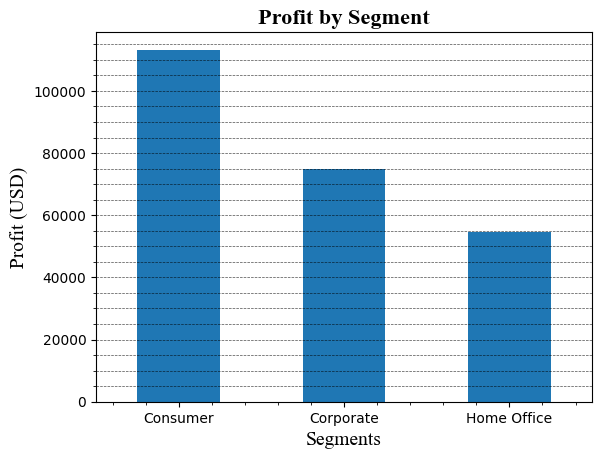

In [18]:

profit_by_segment = seg_grp_obj['Profit'].sum().sort_values(ascending=False)
print()
print("Profit by Segment:")
print(profit_by_segment)
profit_by_segment.plot(kind='bar')
plt.title('Profit by Segment', fontdict=font_title, horizontalalignment='center')
plt.xlabel('Segments', fontdict=font_labels)
plt.ylabel('Profit (USD)', fontdict=font_labels)
plt.grid(True, **grid_dict, axis='y', which='both')
plt.minorticks_on()
plt.xticks(rotation=0)
plt.show()




**key Observations**

- Consistency

    The profits remain consistent with the sale. Although the Home Office segment has the lowest sales, it still generates a notable level of profit (approximately 54k) suggesting potentially higher margins compared to its size

**Insight**

When comparing sales vs profit across segments:

Consumer: 
- Have a high sales and high profit making them the **core growth engine**
Corporate:
- Have moderate sales and profit making Corporate the **stable contributor**
Home Office: 
- Have the lowest sales but decent profit making them have **unnoticed potential**

This tells that the business is not just driven by volume (Consumer), but also has efficient smaller segments (Home Office) that can be expanded.

**Recommendations**

1. Continue Scaling Consumer Segment by maintaining strong marketing and product availability

2. Strengthen Corporate Relatiionships by utilising the long term contract metioned previously

3. **Expand Home Office Segment:**
    - Target, remote workers, freelancers, small businesses, etc and capitalize on them
    
    - Offer affordable starter kits to help attract clients of the Home Office Segment, which has the highest potential

    - Increase sales while maintaining current efficiency

    - Since technology has the highest sales, the business should consider investing more of it into this segment

4. Segment Profitability Strategy
    -Analyze profit margins per segment; which segment converts revenue into profit most efficiently

### Profit Margin

Sales by Segment:
Segment
Consumer       936507.1928
Corporate      554778.0364
Home Office    357168.6233
Name: Sales, dtype: float64

Profit by Segment:
Segment
Consumer       113252.3562
Corporate       74732.8464
Home Office     54499.8836
Name: Profit, dtype: float64

Profit Margin (% of Sales):
Consumer: 12.09%
Corporate: 13.47%
Home Office: 15.26%


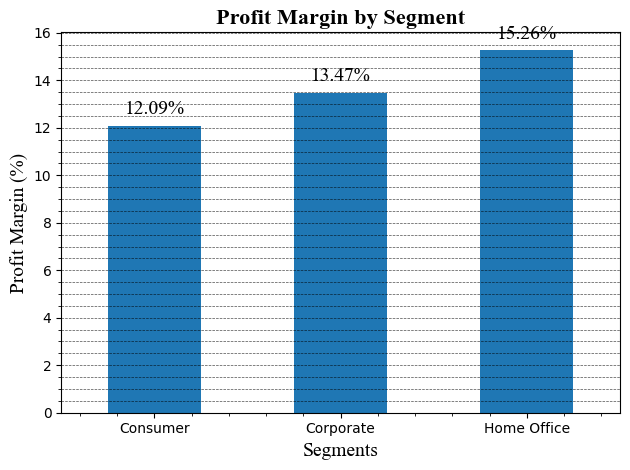

In [19]:
# Calculate profit as percentage of sales
profit_margin_pctg = (profit_by_segment / sales_by_segment) * 100

print("Sales by Segment:")
print(sales_by_segment)
print("\nProfit by Segment:")
print(profit_by_segment)
print("\nProfit Margin (% of Sales):")
for segment, margin in profit_margin_pctg.items():
    print(f"{segment}: {margin:.2f}%")

# Plot profit margin percentage
profit_margin_pctg.plot(kind='bar')
plt.title('Profit Margin by Segment', fontdict=font_title, horizontalalignment='center')
plt.xlabel('Segments', fontdict=font_labels)
plt.ylabel('Profit Margin (%)', fontdict=font_labels)
plt.grid(True, **grid_dict, axis='y', which='both')
plt.minorticks_on()
plt.xticks(rotation=0)

# Add value labels on bars
for i, v in enumerate(profit_margin_pctg):
    plt.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontdict=font_labels)

plt.tight_layout()
plt.show()

---

## KPIs used

The following key performance indicators (KPIs) were used to evaluate business performance:

**Total Sales**

Measures overall revenue generated across different dimensions (time, region, category, and segment).

**Total Profit**

Indicates the net earnings after costs, used to assess overall profitability.
Profit Margin (%)

Calculated as (Profit / Sales × 100), this metric evaluates how efficiently the business converts revenue into profit.

**Sales Growth (Annual Trend)**

Tracks changes in revenue over time to identify business growth patterns.
Seasonal Trends (Monthly Sales & Profit)
Identifies fluctuations in performance throughout the year.

**Regional Performance**

Compares sales and profit across regions to detect geographical strengths and weaknesses.
Category & Product Performance
Evaluates which product categories and individual products drive revenue and profit.

**Customer Segment Performance**

Analyzes contribution from different customer groups (Consumer, Corporate, Home Office).
Compared the rates between the sales an profits of each segment by calculating: (each segment profit / each segment sale) and ploting that

---


## **Key Takeaways**

The analysis reveals that the business is experiencing **steady growth in both sales and profit**, although profit is increasing at a slower rate, indicating a **decline in efficiency**. There is a clear **seasonal pattern**, with performance peaking toward the end of the year and dipping in the early months. Regionally, **the West and East drive the majority of revenue**, while the **Central region underperforms in profitability**, highlighting inefficiencies. From a product perspective, **Technology is the strongest category**, whereas **Furniture generates high sales but very low profit**, making it a key concern. The **Consumer segment is the primary revenue and profit driver**, though opportunities exist to expand the **Home Office segment** and leverage the **efficiency observed in the South region**. Overall, the business should **focus on improving low-margin areas while scaling its high-performing segments and categories**.

---
---